# Introduction

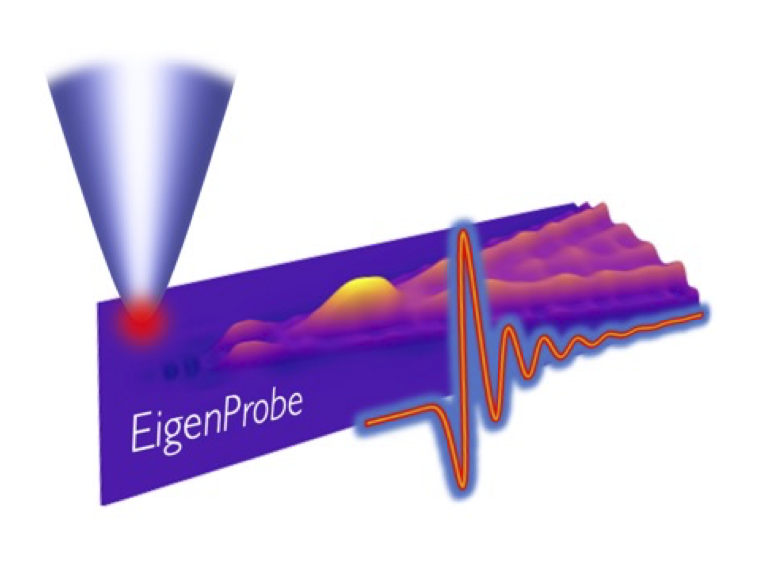

In [1]:
from IPython.display import Image
Image("../Documentation/EigenProbe_Logo.png",width=500)

After building (or loading) a probe and its frequency spectroscopy, we will compute and visualize the near- and far-fields associated with eigenmodes computed at several different energies for the same probe.

# Imports

## General Imports

In [2]:
import os,time,sys,pickle
from matplotlib import pyplot as plt
from importlib import reload

import numba
import numpy as np

## Specialized Imports

In [3]:
from EigenProbe.common.baseclasses import AWA 
from EigenProbe.common.misc import flatten
from EigenProbe.common import numerical_recipes as numrec

from EigenProbe import common
sys.modules['common'] = common # This hook allows to continue to load probe files that were previously saved under an older alias for `common`

## EigenProbe tools

In [4]:
import EigenProbe as EP # https://github.com/asmcleod/EigenProbe.git
from EigenProbe import RotationalMoM as RotMOM
from EigenProbe import ProbeSpectroscopy as PS
from EigenProbe import EigenInversion as EI

sys.modules['ProbeCavityEigenfields'] = EP # This hook allows to continue to load probe files that were previously saved under an older alias for `EigenProbe`

<plotting>:
	Registered colormaps "Warm" and "Warm_r"...
<plotting>:
	Registered colormaps "vanheum" and "vanheum_r"...
<plotting>:
	Registered colormaps "NT-MDT" and "NT-MDT_r"...
<plotting>:
<plotting>:
	Registered colormaps "jingdi" and "jingdi_r"...
<plotting>:
	Registered colormaps "Halcyon" and "Halcyon_r"...
<plotting>:
	Registered colormaps "Cold" and "Cold_r"...
<plotting>:
	Registered colormaps "Sky" and "Sky_r"...
<plotting>:
	Registered colormaps "Gwyddion.net" and "Gwyddion.net_r"...
<plotting>:
	Registered colormaps "BlueRed" and "BlueRed_r"...
<plotting>:
	Registered colormaps "vanheum3" and "vanheum3_r"...
<plotting>:
	Registered colormaps "vanheum2" and "vanheum2_r"...


# Tools for computing and visualizing eigenfields

Some of these tools just function to generate pretty plots.

Others take the current distribution along the probe, and convert it to near- or far-fields.

In [5]:
def gen_tick_positions(scale_start=100, scale_max=10000):

    start, finish = np.floor(np.log10((scale_start, scale_max)))
    finish += 1
    majors = [10 ** x for x in np.arange(start, finish)]
    minors = []
    for idx, major in enumerate(majors[:-1]):
        minor_list = np.arange(majors[idx], majors[idx+1], major)
        minors.extend(minor_list[1:])
    return minors, majors

In [6]:
def plot_probe_and_eigenfield(P,nu=0,zmax=None,rmax=None,Nz=200,clim=1e-3,
                              Nqs_factor=10,
                              sign=+1,probe_alpha=1):
    
    #-- determine probe body
    xs=np.append(P.get_radii(),-P.get_radii()[::-1])*1.1
    ys=np.append(P.get_zs()+P.get_gap(),\
                 P.get_zs()[::-1]+P.get_gap())

    #-- Compute eigenfield
    if zmax is None: zmax=1.25*ys.max()
    if rmax is None: rmax=1.5*xs.max()

    Q=P.get_eigencharge(nu)
    rho=P.get_eigenrho(nu)
    Er,Ez=P.computeEfieldImages(Q,rho=rho,\
                                rs_out=np.linspace(0,rmax,int(Nz*rmax/zmax)),\
                                zs_out=np.linspace(0,zmax,Nz),\
                                rp=None, freq=None, Nqs_factor=Nqs_factor,display=True,mirror_double_images=True)
    Er*=sign; Ez*=sign #overall factor is ad hoc

    #-- plot Ez field  
    plt.figure(figsize=(6,6))  
    Ez.real.plot(cmap='bwr',colorbar=False)
    plt.gca().set_aspect('equal')
    plt.clim(-clim,clim)

    plt.fill(xs,ys,color='gray',alpha=probe_alpha)
    plt.gca().set_aspect('equal')

    for s in plt.gca().spines.values(): s.set_visible(False)
    plt.xticks([])
    plt.yticks([])
    plt.gca().patch.set_visible(False)

    plt.xlabel('')
    plt.ylabel('')
    plt.xlim(-rmax,rmax)
    plt.ylim(0,zmax)
    plt.title(r'$E_z$ field')
    
    #-- plot Er field   
    plt.figure(figsize=(6,6)) 
    Er.real.plot(cmap='bwr',colorbar=False)
    plt.gca().set_aspect('equal')
    plt.clim(-clim,clim)
    
    plt.fill(xs,ys,color='gray',alpha=probe_alpha)
    plt.gca().set_aspect('equal')

    for s in plt.gca().spines.values(): s.set_visible(False)
    plt.xticks([])
    plt.yticks([])
    plt.gca().patch.set_visible(False)

    plt.xlabel('')
    plt.ylabel('')
    plt.xlim(-rmax,rmax)
    plt.ylim(0,zmax)
    plt.title(r'$E_r$ field')
    
    return Ez,Er

In [7]:
def plot_eigenrhos_spectroscopy(eigenrhos,coords,N=3,\
                                linthresh1=.1,linthresh2=.2,figsize=(6,5),\
                               lw=3,alpha=.8,sort_at=50):
    
    colors=zip(np.linspace(1,0,N),[0]*N,np.linspace(0,1,N))
    sorting_key=lambda rho_vs_freq: np.real(rho_vs_freq.cslice[sort_at])
    rhos=sorted(eigenrhos,key=sorting_key)

    plt.figure(figsize=figsize)
    ax1=plt.subplot(121)
    ax2=plt.subplot(122)

    for ID in range(N):
        c=next(colors)
        rho=rhos[ID]
        plt.sca(ax2)
        plt.plot(rho.real,coords,color=c,lw=lw,alpha=alpha)
        plt.sca(ax1)
        plt.plot(rho.imag,coords,color=c,ls='-',lw=lw,alpha=alpha)

    plt.sca(ax1)
    plt.gca().set_xscale('symlog',linthresh=linthresh1)
    plt.gca().set_yscale('log')
    plt.ylim(coords.min(),coords.max())
    plt.ylabel(r'$L$  (microns)',fontsize=22,labelpad=6)
    plt.grid()
    plt.xlabel(r'Im $\rho_i$',fontsize=22,labelpad=12)

    minorticklocs, pos_log_ticks_majors = gen_tick_positions(scale_start=.1, scale_max=10)
    ax1.set_xticks(-np.array(minorticklocs), minor=True)
    plt.tick_params(bottom=True,top=True, which='minor')
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    #ax1.set_xticklabels([str(tl) for tl in -np.array(minorticklocs)])
    plt.xlim(-10,0)

    import matplotlib.ticker as ticker
    for axis in [ax1.xaxis, ax1.yaxis]:
        formatter = ticker.FuncFormatter(lambda y, _: '{:.16g}'.format(y))
        axis.set_major_formatter(formatter)

    plt.sca(ax2)
    plt.gca().set_xscale('symlog',linthresh=linthresh2)
    plt.gca().set_yscale('log')
    plt.ylim(coords.min(),coords.max())
    #ax2.set_yticklabels([1,10,100,1000])
    plt.tick_params(right=True,left=False,\
                    labelleft=False, labelright=True, which='both')
    plt.grid()
    plt.xlabel(r'Re $\rho_i$',fontsize=22,labelpad=12)

    minorticklocs, pos_log_ticks_majors = gen_tick_positions(scale_start=1, scale_max=100)
    ax2.set_xticks(np.array(minorticklocs), minor=True)
    plt.tick_params(bottom=True,top=True, which='minor')
    #ax2.set_xticklabels([0,10,100,1000])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlim(0,500)

    import matplotlib.ticker as ticker
    for axis in [ax2.xaxis, ax2.yaxis]:
        formatter = ticker.FuncFormatter(lambda y, _: '{:.16g}'.format(y))
        axis.set_major_formatter(formatter)

    plt.subplots_adjust(wspace=0)

    #plt.ylim(-1e4,-.001)
    plt.draw()
    
def plot_eigenrhos_spectroscopy2(eigenrhos,coords,N=3,\
                                linthresh1=.1,linthresh2=.2,figsize=(6,5),\
                                lw=3,alpha=.8,sort_at=50):
    
    colors=zip(np.linspace(1,0,N),[0]*N,np.linspace(0,1,N))
    sorting_key=lambda rho_vs_freq: np.real(rho_vs_freq.cslice[sort_at*freq_THz])
    rhos=sorted(eigenrhos,key=sorting_key)

    plt.figure(figsize=figsize)
    ax1=plt.subplot(211)
    ax2=plt.subplot(212)

    for ID in range(N):
        c=next(colors)
        rho=rhos[ID]
        plt.sca(ax1)
        plt.plot(coords,-rho.imag,color=c,lw=lw,alpha=alpha)
        plt.sca(ax2)
        plt.plot(coords,rho.real,color=c,ls='-',lw=lw,alpha=alpha)

    plt.sca(ax1)
    plt.gca().set_yscale('symlog',linthresh=linthresh1)
    plt.ylim(coords.min(),coords.max())
    plt.tick_params(bottom=False,top=True,\
                    labeltop=False, labelbottom=False, which='both')
    plt.ylabel(r'$L$  (microns)',fontsize=22,labelpad=6)
    plt.grid()
    plt.ylabel(r'-Im $\rho_i$',fontsize=22,labelpad=12)

    minorticklocs, pos_log_ticks_majors = gen_tick_positions(scale_start=.1, scale_max=1000)
    ax1.set_yticks(np.array(minorticklocs), minor=True)
    plt.tick_params(left=True, top=True, bottom=False,right=False, which='minor')
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    #ax1.set_xticklabels([str(tl) for tl in -np.array(minorticklocs)])
    plt.xlim(-10,0)

    import matplotlib.ticker as ticker
    for axis in [ax1.xaxis, ax1.yaxis]:
        formatter = ticker.FuncFormatter(lambda y, _: '{:.16g}'.format(y))
        axis.set_major_formatter(formatter)

    plt.sca(ax2)
    plt.gca().set_yscale('symlog',linthresh=linthresh2)
    plt.ylim(coords.min(),coords.max())
    #ax2.set_yticklabels([1,10,100,1000])
    plt.tick_params(bottom=True,top=False,\
                    labeltop=False, labelbottom=True, which='both')
    plt.grid()
    plt.ylabel(r'Re $\rho_i$',fontsize=22,labelpad=12)

    minorticklocs, pos_log_ticks_majors = gen_tick_positions(scale_start=1, scale_max=1000)
    ax2.set_yticks(np.array(minorticklocs), minor=True)
    plt.tick_params(left=True, top=False, bottom=True,right=False, which='minor')
    #ax2.set_xticklabels([0,10,100,1000])
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlim(0,500)

    import matplotlib.ticker as ticker
    for axis in [ax2.xaxis, ax2.yaxis]:
        formatter = ticker.FuncFormatter(lambda y, _: '{:.16g}'.format(y))
        axis.set_major_formatter(formatter)

    plt.subplots_adjust(hspace=0)

    #plt.ylim(-1e4,-.001)
    plt.draw()

In [8]:
def mirror_image(im,axis=0):
    
    new_axes=im.axes
    ax=new_axes[axis]
    new_axes[axis]=np.append(-ax[::-1],ax)
    
    slices=[slice(None) for d in range(im.ndim)]
    slices[axis]=slice(None,None,-1)
    slices=tuple(slices)
    new_im=np.concatenate((im[slices],im),axis=axis)
    
    return EP.AWA(new_im,axes=new_axes,axis_names=im.axis_names)

def compute_Efields_FF(P,Q,rho,rp=None,rs=np.linspace(0,10,200),
                   zs=np.linspace(0,20,400),Nthetas=8,k=None,mirror=True):
    Q=-Q/(Q[0]/np.abs(Q[0])) #just to fix the phase
    if k is None: k=P.get_k()

    zrings=P.get_zs() + P.get_gap()
    rrings=P.get_radii()

    drs = np.gradient(rrings,axis=-1)
    dzs = np.gradient(zrings,axis=-1)
    cos_factors = dzs/np.sqrt(dzs**2+drs**2)

    Rs=rs[:,np.newaxis,np.newaxis] #last index is thetas index, we will sum over
    Zs=zs[np.newaxis,:,np.newaxis] #last index is thetas index, we will sum over
    
    thetas,dthetas = numrec.GetQuadrature(xmin=0,xmax=2*np.pi,quadrature='linear')
    Thetas=thetas[np.newaxis,np.newaxis,:]
    dThetas=dthetas[np.newaxis,np.newaxis,:]
    
    Ez=0; Er=0
    for i in range(len(Q)):
        
        print('Adding ring %i of %i...'%(i+1,len(zrings)))

        djz=Q[i]*cos_factors[i]
        Dx = Rs-np.cos(Thetas)*rrings[i]
        Dy = np.sin(Thetas)*rrings[i]
        Dz = Zs-zrings[i]
        D = np.sqrt(Dx**2+Dy**2+Dz**2)
        kD = k*D
        
        #pointing_radially = k*(Rs - rrings[i]*np.cos(Thetas))/kdRs
        g0 = np.exp(1j*kD)/kD

        # Dyadic elements are built out of "RHat"
        # Reference: Chapter 5: Dyadic Green Functions; https://doi.org/10.1142/9789811203145_0005
        RzHat=(Dz/D)
        RxHat=(Dx/D)
        I_zz = 1 - 1*RzHat*RzHat
        I_xz = 0 - 1*RxHat*RzHat
        I_3zz=1 - 3*RzHat*RzHat
        I_3xz=0 - 3*RxHat*RzHat

        NF = ( (1j/kD) - (1/kD**2) )

        Gzz = (I_zz+I_3zz*NF)*g0
        Gxz = (I_xz+I_3xz*NF)*g0

        Ez_elems = Gzz*djz
        Er_elems = Gxz*djz
        
        #Ez_elems = k**3 * g0 * (1/kdRs**2 - 1j/kdRs - 1) * djz
        #Er_elems = k**3 * g0 * (2/kdRs**2 - 2j/kdRs) * pointing_radially * djz
        #should be some factor here for element radial vector "pointing" along global radial vector

        Ez = np.sum(Ez_elems*dThetas,axis=-1) + Ez
        Er = np.sum(Er_elems*dThetas,axis=-1) + Er

    Ez=EP.AWA(Ez,axes=[rs,zs],axis_names=['r','z'])
    Er=EP.AWA(Er,axes=[rs,zs],axis_names=['r','z'])
    
    if mirror: Er=mirror_image(Er,axis=0)
    if mirror: Ez=mirror_image(Ez,axis=0)
    
    return Er,Ez 

# Build or load probe

In [9]:
a_nm=20
a=a_nm*1e-7 #in cm
L=24e-4 #probe length in cm, assuming added cantilever thickness 4e-4 #Arrow probe: https://www.nanoworld.com/tapping-mode-reflex-coated-afm-tip-arrow-ncr
L_microns=L*1e4
taper_angle=21 # Arrow probe: https://www.researchgate.net/figure/SEM-image-of-an-AFM-tip-attached-to-cantilever_fig6_224406883
geometry='hyperboloid'

WL_THz=300e-4 #300 microns wavelength
freq_THz=1/WL_THz
freq=30*freq_THz # 30 THz

Nsubnodes=2 # 2 or 4 are common values; can be any integer number, but greater than four gains questionably more accuracy and adds great expense.  Experience shows 2 is usually sufficient.
Nnodes=244 # 244 is a good balance of cost and accuracy.  The number will be coerced to the nearest available quadrature grid length.
EP.Probe.dtype = np.complex64

probe_name = '%s_a=%inm_taper=%i_L=%imicrons_Nnodes=%i'%(geometry.capitalize(),a_nm,taper_angle,L_microns,Nnodes)
#probe_name = 'MidIRHyperboloid_FreqDepNormalization_L=%imicrons'%(L*1e4,)
print('Building probe %s...'%probe_name)

Building probe Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244...


The probe is ready to compute interactions with a sample only once its gap distance `d` is set, and once is self-($\omega$-specific) and mirror-($d$-specific) impedance matrices are computed.  The former is computed ($Probe.get_self_impedance$) by adaptive quadrature as a superposition of "Green functions" from each axisymmetric "pulse" basis element along the exterior of the probe's length. (The probe is assumed a perfect conductor, with no internal degrees of freedom.)  The latter is by default also computed (`Probe.get_mirror_impedance`) by adaptive quadrature, or instead with sommerfeld integrals (keyword `sommerfeld=True`); the latter demands a quadrature grid of $\kappa$ values specifiable by `Nkappas` that alternatively defaults to a (naive) best-guess Tanh-Sinh quadrature grid.  The Sommerfeld calculation is faster but convergence must be carefully checked and is not guaranteed for arbitrary geometries.  By contrast, adaptive quadrature calculations should be accurate to machine precision (up to maximum evaluations set by `RotMOM.quadlimit`); fundamental inaccuracies owe to the finite number of "nodes" along the probe. 

Once these impedance matrices are computed, eigenmodes (values $\rho_\nu$ and corresponding vectors $Q_\nu$) are obtained as solutions to the generalized eigenvalue problem described by self- and mirror-impedances.  To obtain the eigenmodes, use `Probe.solve_eigenmodes` with optional conditioning (coercion to positive-definiteness) of the impedance matrices.  The eigenvalues $rho_\nu$ are visualized by `Probe.plot_eigenrhos`; physically meaningful (spatially confined and radiative) eigenmodes have positive real and negative imaginary parts of $\rho_nu$.

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
<__init__._ProbesCollection.__setitem__>:
	<__init__._ProbesCollection.__setitem__>:
		Registering probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!


Text(0, 0.5, 'z (cm)')

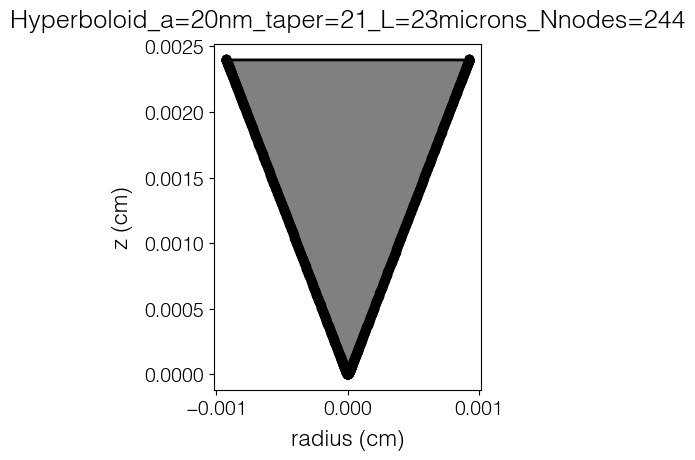

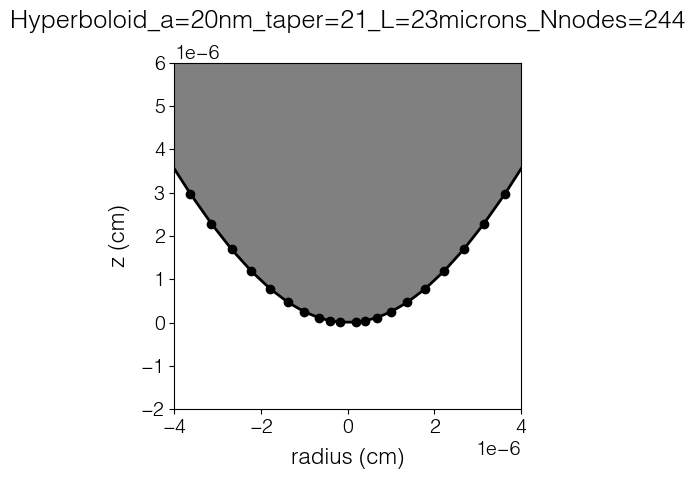

In [10]:
# Load the probe or build the probe
recompute = False
overwrite = False
try:
    if recompute: raise ValueError
    P = EP.load(probe_name,EP.Probe)
except (FileNotFoundError,ValueError): 

    P=EP.Probe(Nnodes=Nnodes,Nsubnodes=Nsubnodes,L=L,quadrature=numrec.TS,\
                     a=a,taper_angle=taper_angle,geometry=geometry,
                freq=freq,gap=a,name=probe_name)

    RotMOM.quadlimit = int(1e4) # maximum evaluations of interaction kernel per node of probe
    #Zmirror = P.get_mirror_impedance(k=0,kappa_min=.1/L,recompute=False,sommerfeld=True,Nkappas=244*8)
    Zmirror = P.get_mirror_impedance(sommerfeld=False)
    #Zself = P.get_self_impedance(k=P.get_k(),recompute=True)
    rhos,Js = P.solve_eigenmodes(condition_ZM=True,condition_ZS=False,ZMthresh=0,recompute_impedance=False)
    
    try: EP.save(P,overwrite=overwrite)
    except OSError: pass
    
ztip=P.get_gap()
zs=P.get_zs()
Rs=P.get_radii()
k=P.get_k()
a=P.get_a() # Probe radius

P.plot_geometry()
plt.gca().set_aspect('equal')
plt.xlabel('radius (cm)')
plt.ylabel('z (cm)')

P.plot_geometry()
plt.xlim(-2*a,2*a)
plt.ylim(-a,3*a)
plt.xlabel('radius (cm)')
plt.ylabel('z (cm)')

#Zmirror = P.get_mirror_impedance(k=P.get_k(),nonsingular=False,recompute=True)
#Zmirror = P.get_mirror_impedance(k=0,nonsingular=False,recompute=True)
#Zmirror = P.get_mirror_impedance(k=P.get_k(),farfield=False,recompute=True,sommerfeld=True,Nkappas=244*8,rp=rp_au,\
#                                kappa_min=P.get_k()*.01)

(0.0, 15.0)

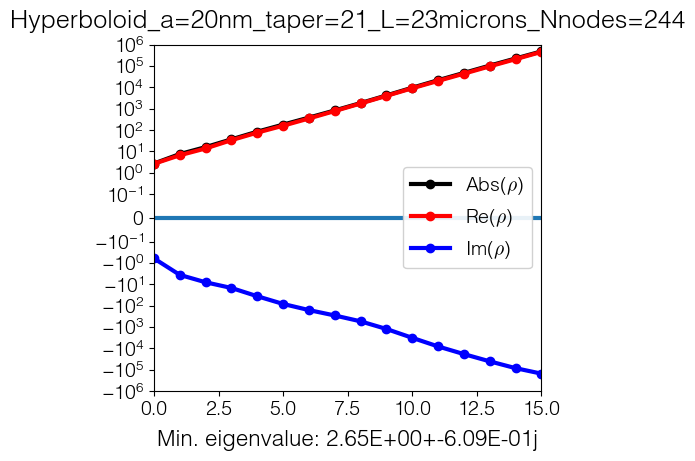

In [11]:
P.plot_eigenrhos()
plt.xlim(0,15)

# Probe Frequency Spectroscopy

## Load or build spectroscopy

In [12]:
freqs=np.linspace(0.5,80,200)*freq_THz

recompute=False
save=False
overwrite=False

try:
    if recompute: raise ValueError
    ProbeFreqSpectroscopy = EP.load(P, PS.ProbeFrequencySpectroscopyParallel, overwrite_probe=True)
    
except (FileNotFoundError,ValueError):
    ProbeFreqSpectroscopy = PS.ProbeFrequencySpectroscopyParallel(Probe=P, freqs=freqs,
                                                                 ncpus=8, backend='loky',
                                                                 Nmodes=20, reversed=False)
    if save:
        try: EP.save(ProbeFreqSpectroscopy,overwrite=overwrite)
        except OSError: # didn't overwrite
            print('Tried to save ProbeFreqSpectroscopy, but save file already exists.  Skipping.  You can choose `overwrite=True`.')

Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_ProbeFrequencySpectroscopy.pickle"...
Attemping to load from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"...
<__init__._ProbesCollection.__setitem__>:
	<__init__._ProbesCollection.__setitem__>:
		Overwriting registered probe "Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244"...
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_Probe.pickle"!
Successfully loaded from file "/Users/alexandersmcleod/tools/python/EigenProbe/Probe models/(Hyperboloid_a=20nm_taper=21_L=23microns_Nnodes=244)_ProbeFrequencySpectroscopy.pickle"!


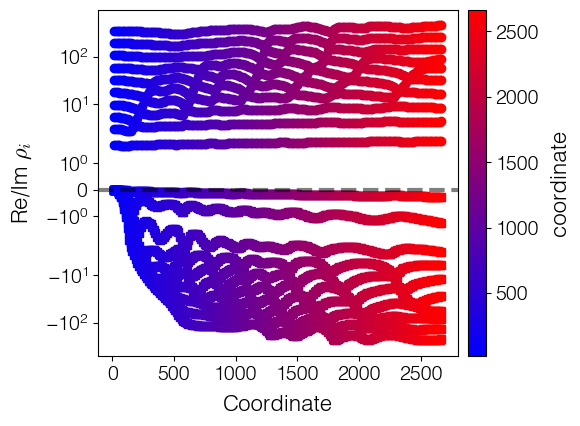

In [13]:
ProbeFreqSpectroscopy.plot_eigenrhos_scatter(Nmodes=10,versus_coord=True)
plt.gcf().axes[0].set_xscale('linear')

## Classify and plot dispersion of probe poles

Now that frequency spectroscopy has been computed, ideally there at at least $N_\mathrm{max}$ eigenmodes mutually identified at all frequencies.  Right now, this is just a disordered collection of modes.  Now it is time to "classify" them by an eigenmode index $\nu$, so that later calculations can deal with distinct eigenmodes as functions of $\omega$.  A proper classification will sort eigenmodes (smaller values of $\rho(\omega)$) with higher confinement to lower values of index $\nu$, and will also maintain smooth evolution of the resulting eigenvalue functions $\rho_\nu(\omega)$.  Calling `ProbeFreqSpectroscopy` with suitable arguments will attempt a classification.  A successful classification shows continuous evolution of the functions $\rho_\nu(\omega)$ returned as 2D array by `ProbeFreqSpectroscopy.get_eigenrhos_AWA`; the continuity (or not) of these classified functions can be visualized with `ProbeFreqSpectroscopy.plot_eigenrhos`.

It is natural that the eigenmodes and $\rho(\omega)$ (and their "brightness") will show "resonances" at frequencies of antenna modes of the probe, where the eigenmodes will show selectively higher dipole / quadrupole / etc. moments along the probe's length in comparison to the free-space wavelength.  In this respect, the probe-sample near-field interaction is somewhat modulated through this coupling between eigenmodes and far-field radiance.

After `ProbeFreqSpectroscopy` has computed this dependence and classified the eigenmodes, how are they used?  `ProbeFreqSpectroscopy.set_eigenset(Probe,freq)` will load eigenmodes computed at $\omega$ (`freq`) into `Probe`.  (These can in principle also be loaded into the corresponding `EncodedEigenfields` instance to "update" the eignemodes at reference probe-sample gap $d_0$, although this feature hasn't been implemented yet.)

In [14]:
ProbeFreqSpectroscopy(Nmodes=20,reverse=False,by_rho=True,debug=False)
eigenrhos = ProbeFreqSpectroscopy.get_eigenrhos_AWA(Nmodes=20)
eigencharges = ProbeFreqSpectroscopy.get_eigencharges_AWA()

Classifying eigensets by eigenindex...
	Progress: 99.50%<ProbeSpectroscopy.ProbeFrequencySpectroscopyParallel.align_eigencharge_signs>:
	<ProbeSpectroscopy.ProbeFrequencySpectroscopyParallel.align_eigencharge_signs>:
		Aligning signage of 20 eigenmode charges over 200 coordinates...


Text(0.5, 0, 'Frequency  (cm$^{-1}$)')

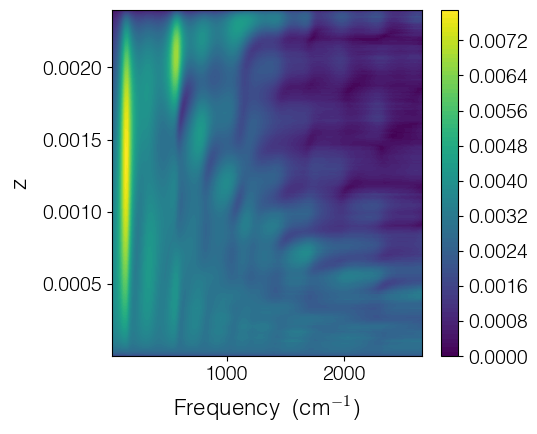

In [15]:
np.abs(eigencharges[0]).plot(plotter=plt.contourf) # Ideally, the profile of eigencharges evolves smoothly with `
plt.xlabel(r'Frequency  (cm$^{-1}$)')

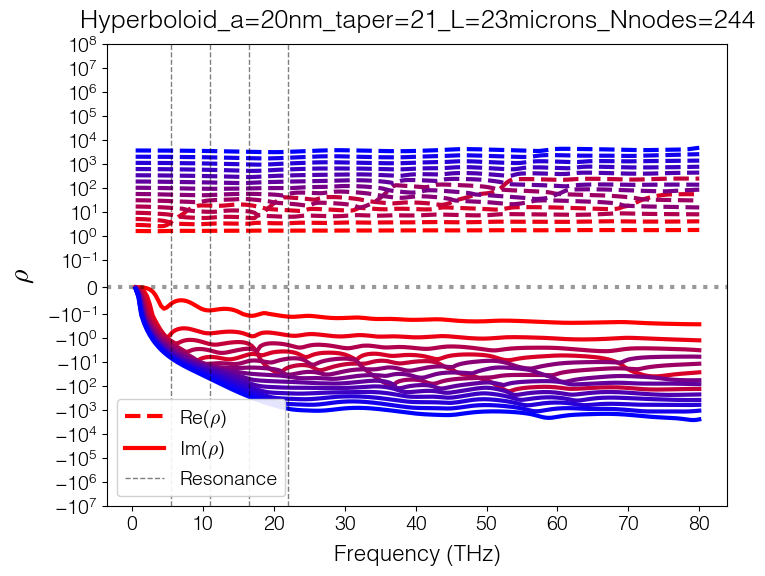

In [16]:
N=14
colors=zip(np.linspace(1,0,N),[0]*N,np.linspace(0,1,N))
plt.figure(figsize=(8,6))

freqs=eigenrhos.axes[1]
for n in range(N):
    c=next(colors)

    if n==0:
        label1=r'Re($\rho$)'
        label2=r'Im($\rho$)'
    else: label1=label2=None
        
    rhos=eigenrhos[n]
    plt.plot(freqs/freq_THz,rhos.real,marker='',color=c,label=label1,ls='--')
    plt.plot(freqs/freq_THz,rhos.imag,marker='',color=c,label=label2)
    
plt.gca().set_yscale('symlog',linthresh=.1)
plt.ylim(-1e7,1e8)
#plt.xlim(.0074,.0076)
#plt.xlim(np.min(freqs),.002)
plt.xlabel('Frequency (THz)')
plt.ylabel(r'$\rho$',fontsize=20)
plt.legend(frameon=True)

#--- Plot some antenna mode frequencies

f=.88 # Geometry of the probe influences at what energies the antenna resonances appear.  This proportionality factor is very much non-universal.
kwargs=dict(color='k',ls='--',alpha=.5,lw=1)
plt.axvline(f/(2*L)/freq_THz,**kwargs) #This is where probe ~ lambda/2 antenna - radiative Q?
plt.axvline(f/L/freq_THz,**kwargs) #This is where probe ~ lambda antenna - radiative Q?
plt.axvline(f*3/(2*L)/freq_THz,**kwargs)
plt.axvline(f*2/(L)/freq_THz,label='Resonance',**kwargs)

plt.axhline(0,ls=':',color='k',alpha=.4)
plt.title(ProbeFreqSpectroscopy.get_probe().get_name())
plt.legend()

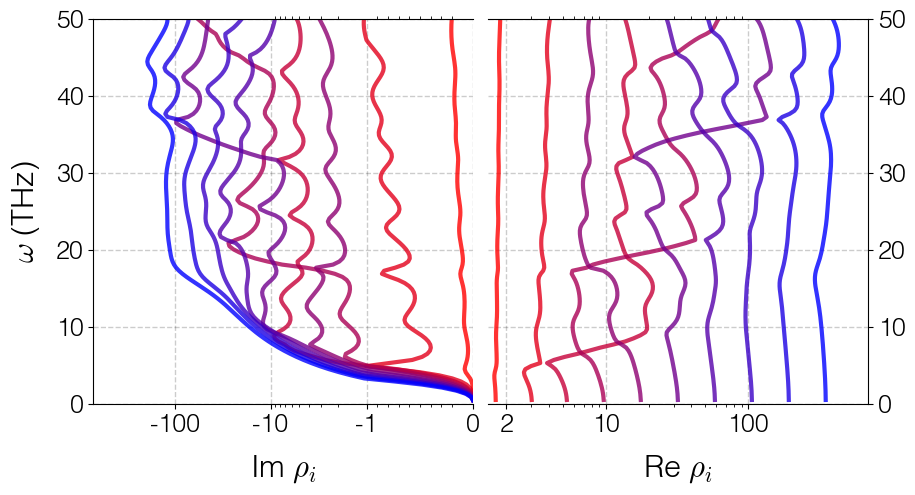

In [17]:
freqs_THz = freqs/freq_THz
plot_eigenrhos_spectroscopy(eigenrhos,freqs_THz,N=10,\
                            linthresh1=1,linthresh2=1,figsize=(10,5))
ax1,ax2=plt.gcf().axes
ax1.set_ylabel('$\omega$ (THz)',labelpad=10)
#ax1.set_xscale('symlog',linthresh=1)
ax1.set_xlim(-700,0)
ax2.set_xlim(1.5,7e2)

ax1.set_yscale('linear')
ax2.set_yscale('linear')
ax1.set_ylim(0,50)
ax2.set_ylim(0,50)
#ax2.set_xscale('symlog',linthresh=1)
ax2.set_xticks([2,10,100])
plt.subplots_adjust(wspace=.04)
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)



# Plot Eigenfields

## Compare two eigenfields at fixed energy

In [18]:
freq = 30*freq_THz
print('Plotting eigenmodes at energy: %1.2f THz'%(freq/freq_THz))
ProbeFreqSpectroscopy.set_eigenset(P,freq)

Plotting eigenmodes at energy: 30.00 THz
<ProbeSpectroscopy.ProbeFrequencySpectroscopyParallel.get_probe_at_coord>:
	<ProbeSpectroscopy.ProbeFrequencySpectroscopyParallel.get_probe_at_coord>:
		Updating eigenrhos to coordinate 1.00E+03...
	Updating eigencharges...
	Updating self impedance...
	Updating mirror impedance...


### First eigenfield

In [19]:
nu=0

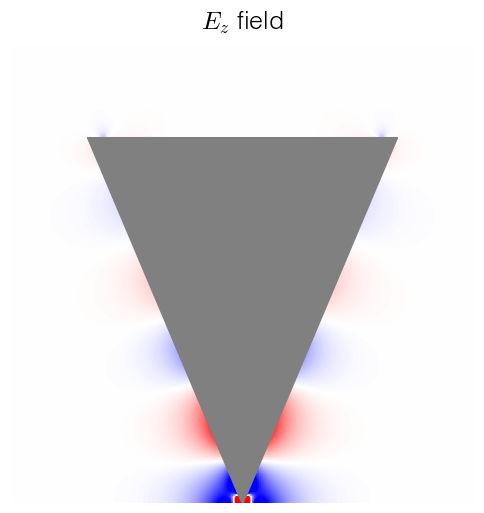

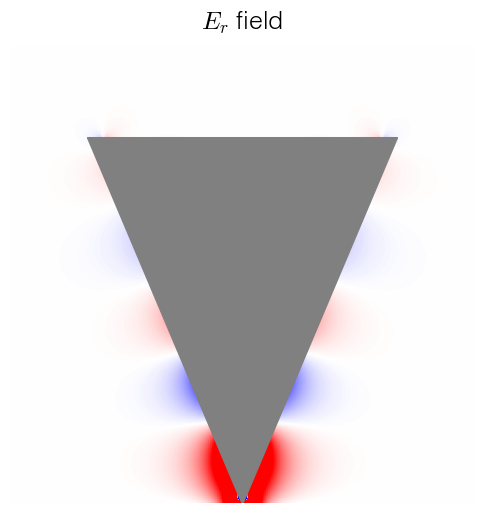

In [20]:
Ez,Er = plot_probe_and_eigenfield(P,nu=nu,zmax=None,rmax=None,Nz=200,clim=1e5,sign=+1);

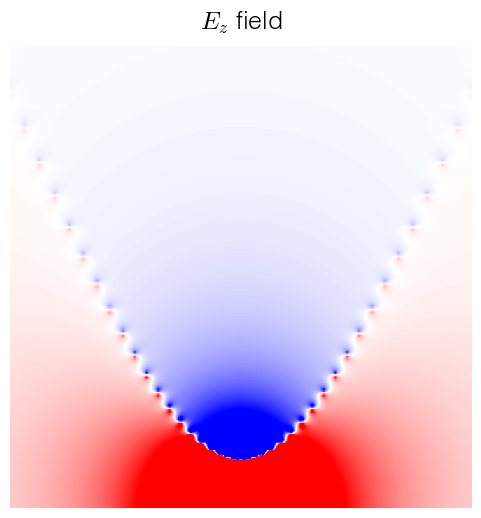

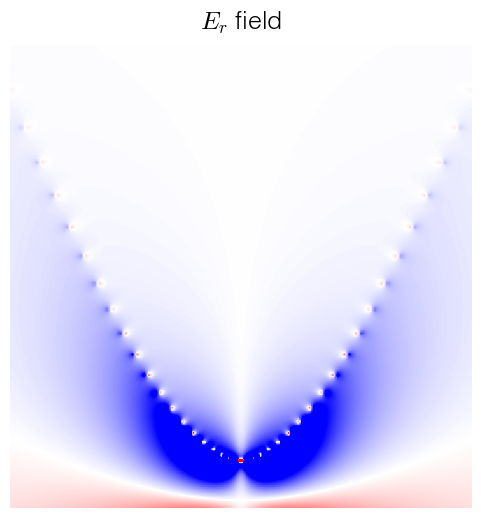

In [21]:
# Zoom-in with a view spanning 10 probe radii, this allows to actually observe discretization of the probe
span=10
Ez,Er = plot_probe_and_eigenfield(P,nu=nu,zmax=span*a,rmax=span/2*a,Nz=200,clim=1e8,sign=+1,probe_alpha=0);

### Tenth eigenfield

In [22]:
nu=10

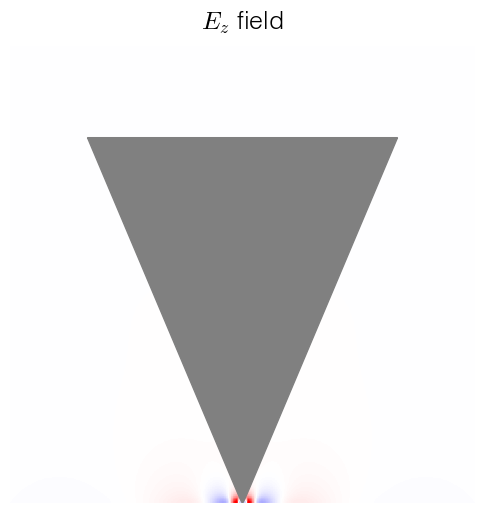

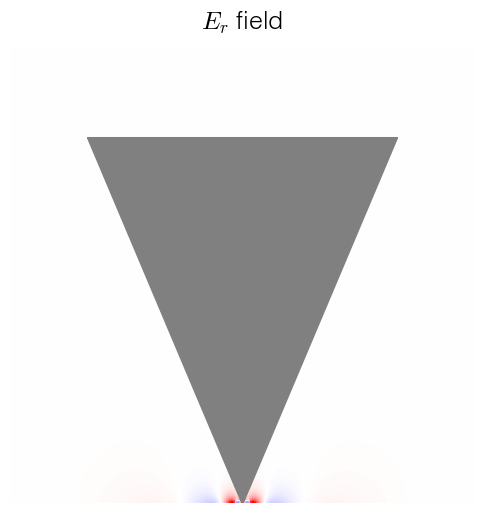

In [23]:
Ez,Er = plot_probe_and_eigenfield(P,nu=nu,zmax=None,rmax=None,Nz=200,clim=1e9,sign=+1);

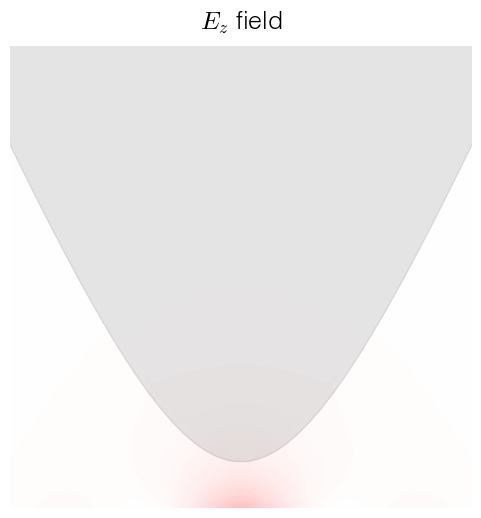

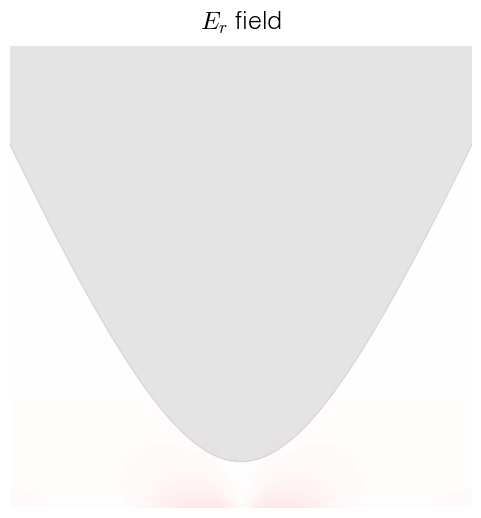

In [24]:
# Zoom-in with a view spanning 10 probe radii, this allows to actually observe discretization of the probe
span=10
Ez,Er = plot_probe_and_eigenfield(P,nu=nu,zmax=span*a,rmax=span/2*a,Nz=200,clim=1e12,sign=+1,probe_alpha=0.2);

## Compare one eigenfield at two energies

In [25]:
nu=0
freq1=freq_THz
freq2=50*freq_THz

Plotting eigenmode for first energy: 1.00 THz
<ProbeSpectroscopy.ProbeFrequencySpectroscopyParallel.get_probe_at_coord>:
	<ProbeSpectroscopy.ProbeFrequencySpectroscopyParallel.get_probe_at_coord>:
		Updating eigenrhos to coordinate 3.00E+01...
	Updating eigencharges...
	Updating self impedance...
	Updating mirror impedance...


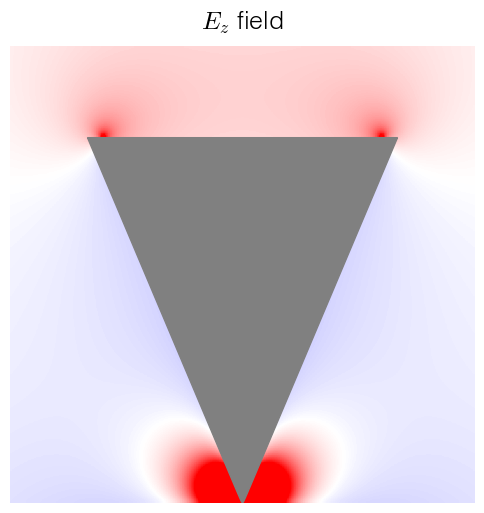

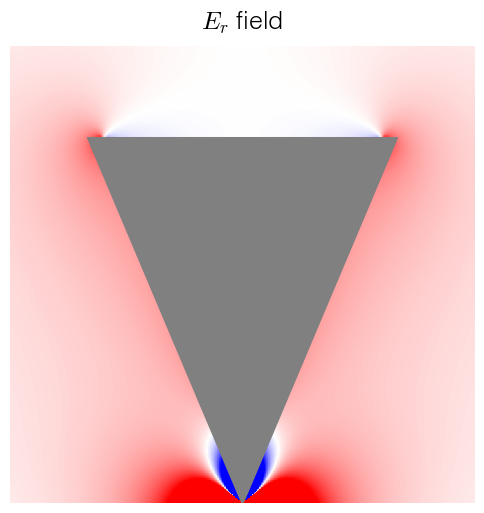

In [26]:
print('Plotting eigenmode for first energy: %1.2f THz'%(freq1/freq_THz))
ProbeFreqSpectroscopy.set_eigenset(P,freq1)
Ez,Er = plot_probe_and_eigenfield(P,nu=nu,zmax=None,rmax=None,Nz=200,clim=1e4,sign=+1);

Plotting eigenmode for first energy: 50.00 THz
<ProbeSpectroscopy.ProbeFrequencySpectroscopyParallel.get_probe_at_coord>:
	<ProbeSpectroscopy.ProbeFrequencySpectroscopyParallel.get_probe_at_coord>:
		Updating eigenrhos to coordinate 1.67E+03...
	Updating eigencharges...
	Updating self impedance...
	Updating mirror impedance...


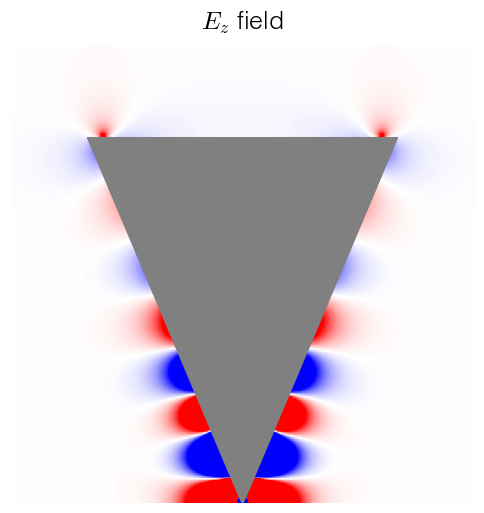

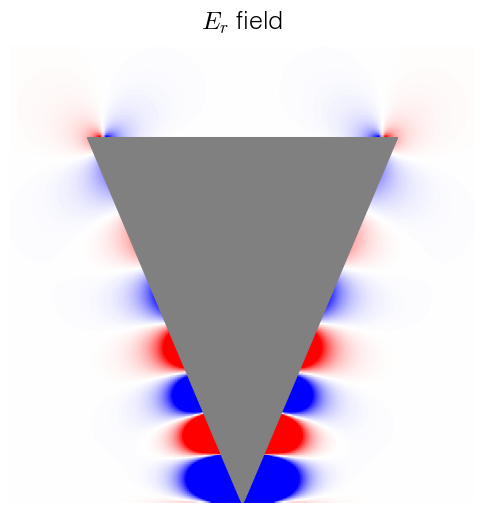

In [27]:
print('Plotting eigenmode for first energy: %1.2f THz'%(freq2/freq_THz))
ProbeFreqSpectroscopy.set_eigenset(P,freq2)
Ez,Er = plot_probe_and_eigenfield(P,nu=nu,zmax=None,rmax=None,Nz=200,clim=1e4,sign=+1);

## Visualize far-field of probe

In [49]:
freq = 30*freq_THz
print('Plotting eigenmodes at energy: %1.2f THz'%(freq/freq_THz))
ProbeFreqSpectroscopy.set_eigenset(P,freq)

Plotting eigenmodes at energy: 30.00 THz
<EigenProbe.ProbeSpectroscopy.ProbeFrequencySpectroscopyParallel.get_probe_at_coord>:
	<EigenProbe.ProbeSpectroscopy.ProbeFrequencySpectroscopyParallel.get_probe_at_coord>:
		Updating eigenrhos to coordinate 1.00E+03...
	Updating eigencharges...
	Updating self impedance...
	Updating mirror impedance...


In [50]:
nu=0
Q=np.array(P.get_eigencharge(nu))
rmax=20*P.get_radii().max()
zmax=20*P.get_zs().max()
Er,Ez=compute_Efields_FF(P,Q,rho=0,rp=None,rs=np.linspace(0,rmax,100),
                         zs=np.linspace(-zmax/2,zmax/2,100),Nthetas=20,k=P.get_k(),mirror=True)

Adding ring 1 of 382...
Adding ring 2 of 382...
Adding ring 3 of 382...
Adding ring 4 of 382...
Adding ring 5 of 382...
Adding ring 6 of 382...
Adding ring 7 of 382...
Adding ring 8 of 382...
Adding ring 9 of 382...
Adding ring 10 of 382...
Adding ring 11 of 382...
Adding ring 12 of 382...
Adding ring 13 of 382...
Adding ring 14 of 382...
Adding ring 15 of 382...
Adding ring 16 of 382...
Adding ring 17 of 382...
Adding ring 18 of 382...
Adding ring 19 of 382...
Adding ring 20 of 382...
Adding ring 21 of 382...
Adding ring 22 of 382...
Adding ring 23 of 382...
Adding ring 24 of 382...
Adding ring 25 of 382...
Adding ring 26 of 382...
Adding ring 27 of 382...
Adding ring 28 of 382...
Adding ring 29 of 382...
Adding ring 30 of 382...
Adding ring 31 of 382...
Adding ring 32 of 382...
Adding ring 33 of 382...
Adding ring 34 of 382...
Adding ring 35 of 382...
Adding ring 36 of 382...
Adding ring 37 of 382...
Adding ring 38 of 382...
Adding ring 39 of 382...
Adding ring 40 of 382...
Adding ri

Text(0.5, 1.0, 'Field Amplitude')

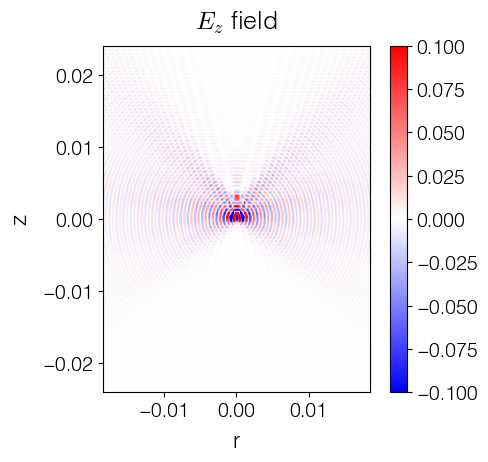

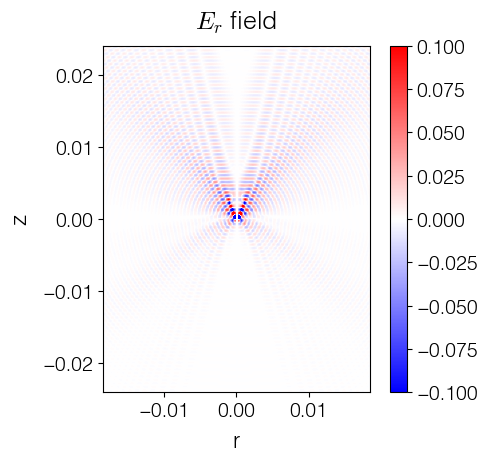

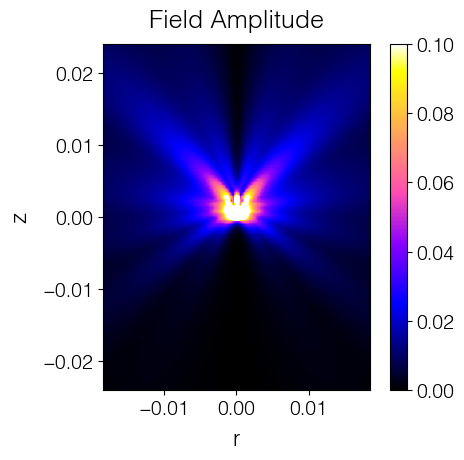

In [51]:
Ez.real.plot(cmap='bwr')
cl=1e-1
plt.clim(-cl,cl)
plt.gca().set_aspect('equal')
plt.title('$E_z$ field')

plt.figure()
Er.real.plot(cmap='bwr')
plt.clim(-cl,cl)
plt.gca().set_aspect('equal')
plt.title('$E_r$ field')

plt.figure()
np.sqrt(np.abs(Er)**2+np.abs(Ez)**2).plot(cmap='gnuplot2')
plt.clim(0,cl)
plt.gca().set_aspect('equal')
plt.title('Field Amplitude')

Computing brightness versus angle using excitation type:
 <class 'ProbeCavityEigenfields.RotationalMoM.EPlaneWaveFF'>


Text(0.5, 1.0, 'Radiation amplitude from eigenmode $\\nu=0$')

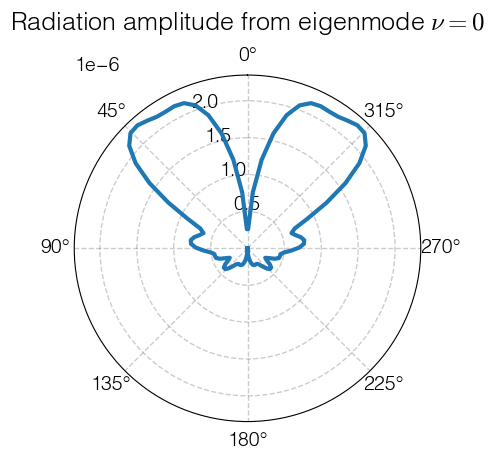

In [52]:
print('Computing brightness versus angle using excitation type:\n',P.defaults['excitation'])

angles=np.linspace(-180,180,100)
Bs=P.get_brightness(Q,illum_angles=angles)
plt.polar(np.deg2rad(angles),np.abs(Bs))
plt.gca().set_theta_zero_location("N")

plt.title(r'Radiation amplitude from eigenmode $\nu=%i$'%nu)


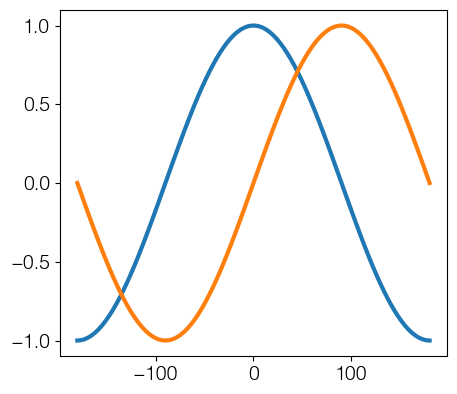

In [61]:
plt.plot(angles,np.sin(np.deg2rad(90-angles)))
plt.plot(angles,np.cos(np.deg2rad(90-angles)))

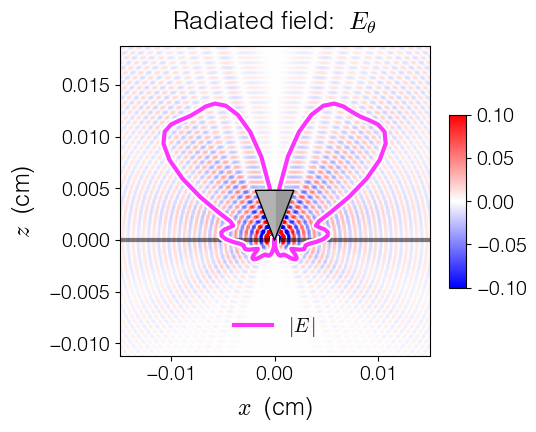

In [108]:
R,Z= Er.axis_grids
D= np.sqrt(R**2+Z**2)
Sin=np.abs(R)/D
Cos=Z/D
E_theta = Er * Cos - Ez * Sin

xlim=.015

plt.figure()
im=E_theta.real.plot(cmap='bwr',colorbar=False)
plt.clim(-cl,cl)
plt.gca().set_aspect('equal')
plt.title(r'Radiated field:  $E_\theta$')

plt.colorbar(im, shrink=0.5, aspect=10)

Babs=np.abs(Bs)
Babs /= Babs.max()
Babs*=xlim
Bz=Babs*np.sin(np.deg2rad(90-angles))
Br=Babs*np.cos(np.deg2rad(90-angles))
#Br*=1e-1
#Bz*=1e-1

plt.axhline(0,ls='-',color='k',alpha=.5)
plt.plot(Br,Bz,color='w',lw=6)
plt.plot(Br,Bz,color=(1,0,1),alpha=.8,label=r'$|E\,|$')

plt.xlim(-xlim,xlim)
plt.ylim(-0.75*xlim,1.25*xlim)

zoom_probe=2
probe_radii=P.get_radii()*zoom_probe
probe_zs = P.get_zs()*zoom_probe
plt.fill_between(probe_radii,probe_zs,probe_zs.max(),color=(.6,.6,.6),ls='-',zorder=9)
plt.fill_between(-probe_radii,probe_zs,probe_zs.max(),color=(.7,.7,.7),ls='-',zorder=9)
probe_zs = np.append(probe_zs,probe_zs.max())
probe_radii=np.append(probe_radii,0)
plt.plot(probe_radii,probe_zs,color='k',lw=1,zorder=10)
plt.plot(-probe_radii,probe_zs,color='k',lw=1,zorder=10)

plt.xlabel('$x$  (cm)',fontsize=17)
plt.ylabel('$z$  (cm)',fontsize=17)

plt.legend(loc='lower center',frameon=False)

## Compare radiation field from several eigenmodes

Computing brightness versus angle using excitation type:
 <class 'ProbeCavityEigenfields.RotationalMoM.EPlaneWaveFF'>


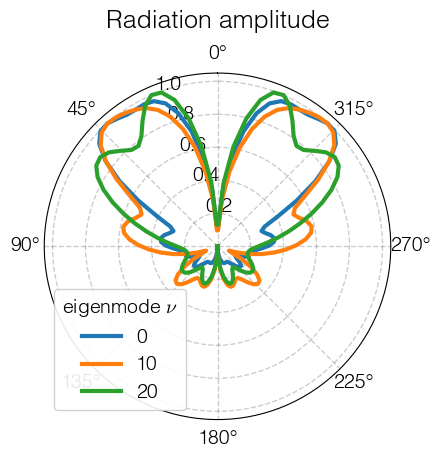

In [32]:
angles=np.linspace(-180,180,100)
print('Computing brightness versus angle using excitation type:\n',P.defaults['excitation'])

for nu in [0,10,20]:
    
    Q=np.array(P.get_eigencharge(nu))
    Bs=P.get_brightness(Q,illum_angles=angles)
    Bs /= np.abs(Bs).max()

    #plt.figure()
    plt.polar(np.deg2rad(angles),np.abs(Bs),label=nu)
    plt.gca().set_theta_zero_location("N")
    
plt.title(r'Radiation amplitude')
plt.legend(title=r'eigenmode $\nu$')


In [33]:
rad_intensities = []
for nu in range(40):
    Q=np.array(P.get_eigencharge(nu))
    Bs=P.get_brightness(Q,illum_angles=angles)
    rad_intensity = np.sum(np.abs(Bs)**2*np.sin(angles))
    rad_intensities.append(rad_intensity)

rad_intensities = np.array(rad_intensities)
    

Text(0, 0.5, 'Manually computed')

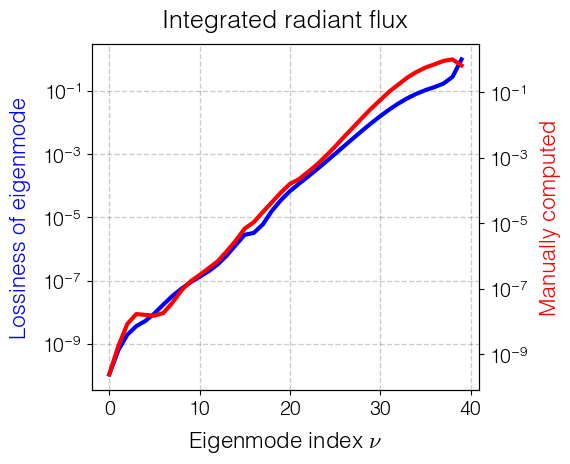

In [34]:
plt.title('Integrated radiant flux')
rho_im=-P.get_eigenrhos().imag
plt.semilogy(rho_im/rho_im.max(),color='b')
plt.ylabel('Lossiness of eigenmode',color='b')
plt.xlabel(r'Eigenmode index $\nu$')
plt.grid()

plt.twinx()
plt.semilogy(rad_intensities/rad_intensities.max(),color='r')
plt.ylabel('Manually computed',color='r')
